# 🏠 House Rent Prediction - Complete Regression Capstone Project

## 📖 Project Overview
This capstone project demonstrates comprehensive regression analysis for house rent prediction.
We implement all essential regression concepts with practical examples and insights.

### 🎯 Complete Implementation Includes:
1. **Exploratory Data Analysis** - Data insights and visualizations
2. **Data Preprocessing** - Cleaning and feature engineering
3. **Linear Regression** - From scratch implementation
4. **Gradient Descent** - Optimization algorithm
5. **Bias-Variance Analysis** - Model complexity evaluation
6. **Regularization** - L1 (Lasso) and L2 (Ridge) techniques
7. **Cross-Validation** - Robust model evaluation
8. **Polynomial Regression** - Non-linear relationships
9. **Model Comparison** - Performance analysis and conclusions

## 1. Import Libraries and Load Data

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')
print('🎯 Ready for comprehensive regression analysis!')

✅ All libraries imported successfully!
🎯 Ready for comprehensive regression analysis!


In [ ]:
# Load the dataset
df = pd.read_csv('/content/House_Rent_Dataset.csv')

print(f'📊 Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'📋 Columns: {list(df.columns)}')
print('\n🔍 First 5 rows:')
df.head()

📊 Dataset loaded: 4746 rows, 12 columns
📋 Columns: ['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']

🔍 First 5 rows:


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## 2. Exploratory Data Analysis (EDA)

In [ ]:
# Basic dataset information
print('📈 DATASET OVERVIEW')
print('=' * 50)
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

print('\n🔍 DATA TYPES:')
print(df.dtypes)

print('\n❓ MISSING VALUES:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('✅ No missing values!')
else:
    print(missing[missing > 0])

print('\n📊 BASIC STATISTICS:')
df.describe()

📈 DATASET OVERVIEW
Shape: (4746, 12)
Memory: 2.35 MB

🔍 DATA TYPES:
Posted On            object
BHK                   int64
Rent                  int64
Size                  int64
Floor                object
Area Type            object
Area Locality        object
City                 object
Furnishing Status    object
Tenant Preferred     object
Bathroom              int64
Point of Contact     object
dtype: object

❓ MISSING VALUES:
✅ No missing values!

📊 BASIC STATISTICS:


,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


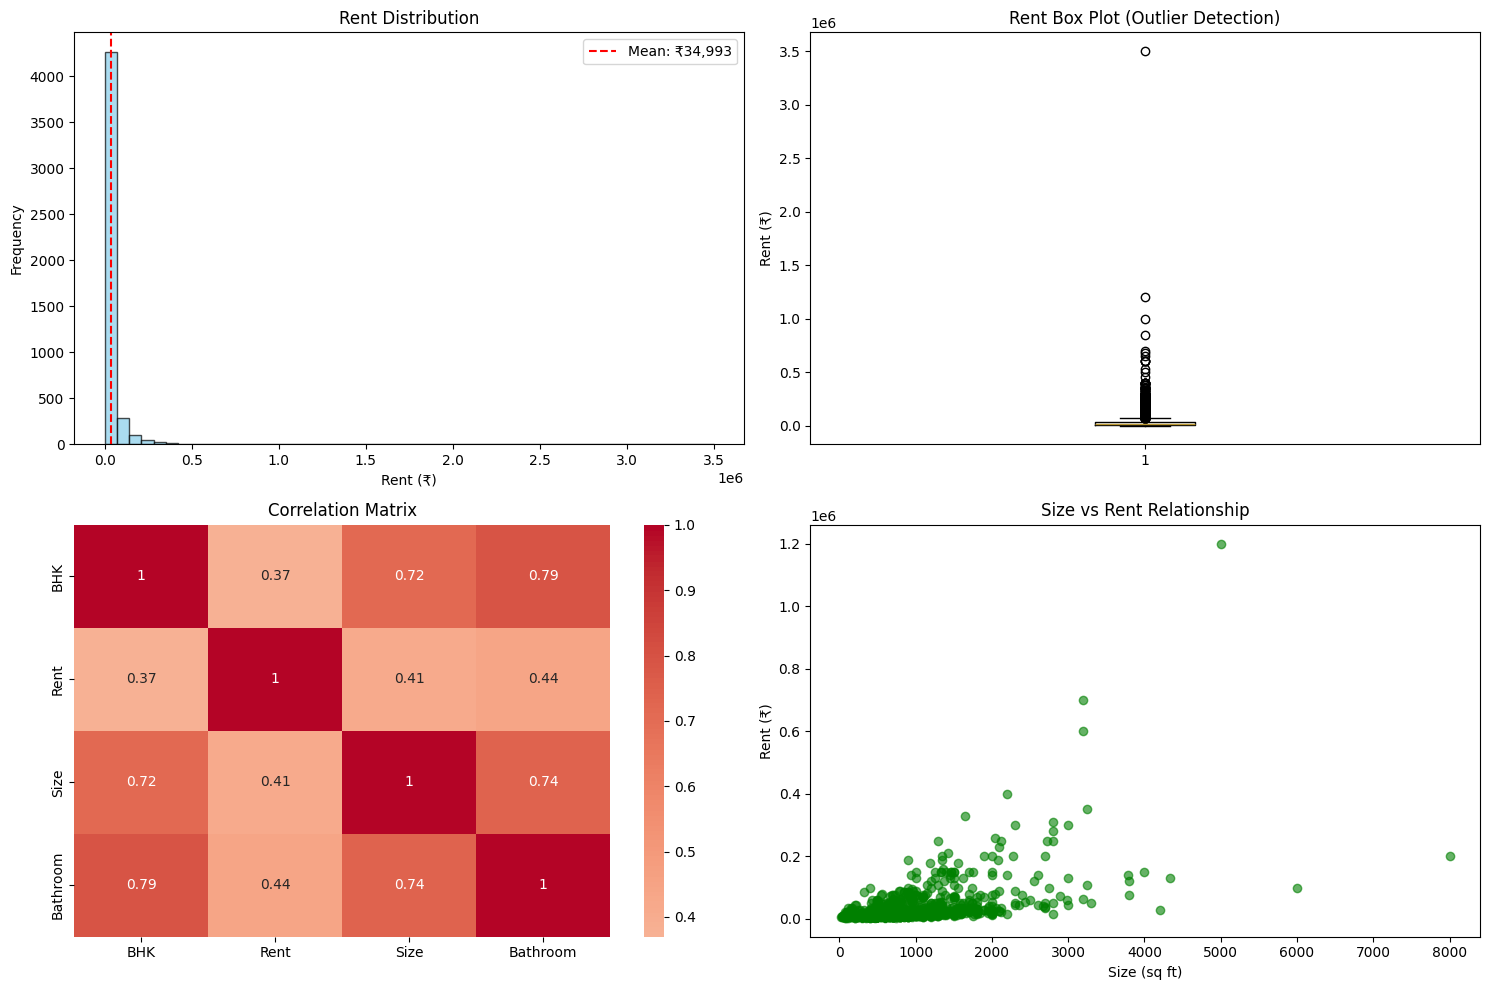

💡 KEY INSIGHTS FROM EDA:
• Average Rent: ₹34,993
• Rent Range: ₹1,200 - ₹3,500,000
• Data Skewness: 21.41 (Right-skewed)
• Size-Rent Correlation: 0.414
• BHK-Rent Correlation: 0.370


In [ ]:
# Comprehensive rent analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Rent distribution
axes[0,0].hist(df['Rent'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0,0].set_title('Rent Distribution')
axes[0,0].set_xlabel('Rent (₹)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df['Rent'].mean(), color='red', linestyle='--', label=f'Mean: ₹{df["Rent"].mean():,.0f}')
axes[0,0].legend()

# Box plot for outliers
axes[0,1].boxplot(df['Rent'])
axes[0,1].set_title('Rent Box Plot (Outlier Detection)')
axes[0,1].set_ylabel('Rent (₹)')

# Correlation heatmap
numeric_cols = ['BHK', 'Rent', 'Size', 'Bathroom']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,0])
axes[1,0].set_title('Correlation Matrix')

# Size vs Rent scatter
sample_data = df.sample(min(1000, len(df)))
axes[1,1].scatter(sample_data['Size'], sample_data['Rent'], alpha=0.6, color='green')
axes[1,1].set_title('Size vs Rent Relationship')
axes[1,1].set_xlabel('Size (sq ft)')
axes[1,1].set_ylabel('Rent (₹)')

plt.tight_layout()
plt.show()

# Print key insights
print('💡 KEY INSIGHTS FROM EDA:')
print(f'• Average Rent: ₹{df["Rent"].mean():,.0f}')
print(f'• Rent Range: ₹{df["Rent"].min():,.0f} - ₹{df["Rent"].max():,.0f}')
print(f'• Data Skewness: {df["Rent"].skew():.2f} (Right-skewed)' if df['Rent'].skew() > 1 else f'• Data Skewness: {df["Rent"].skew():.2f}')
print(f'• Size-Rent Correlation: {correlation_matrix.loc["Size", "Rent"]:.3f}')
print(f'• BHK-Rent Correlation: {correlation_matrix.loc["BHK", "Rent"]:.3f}')

# 🏠 House Rent Prediction - Complete Regression Capstone Project

# Project


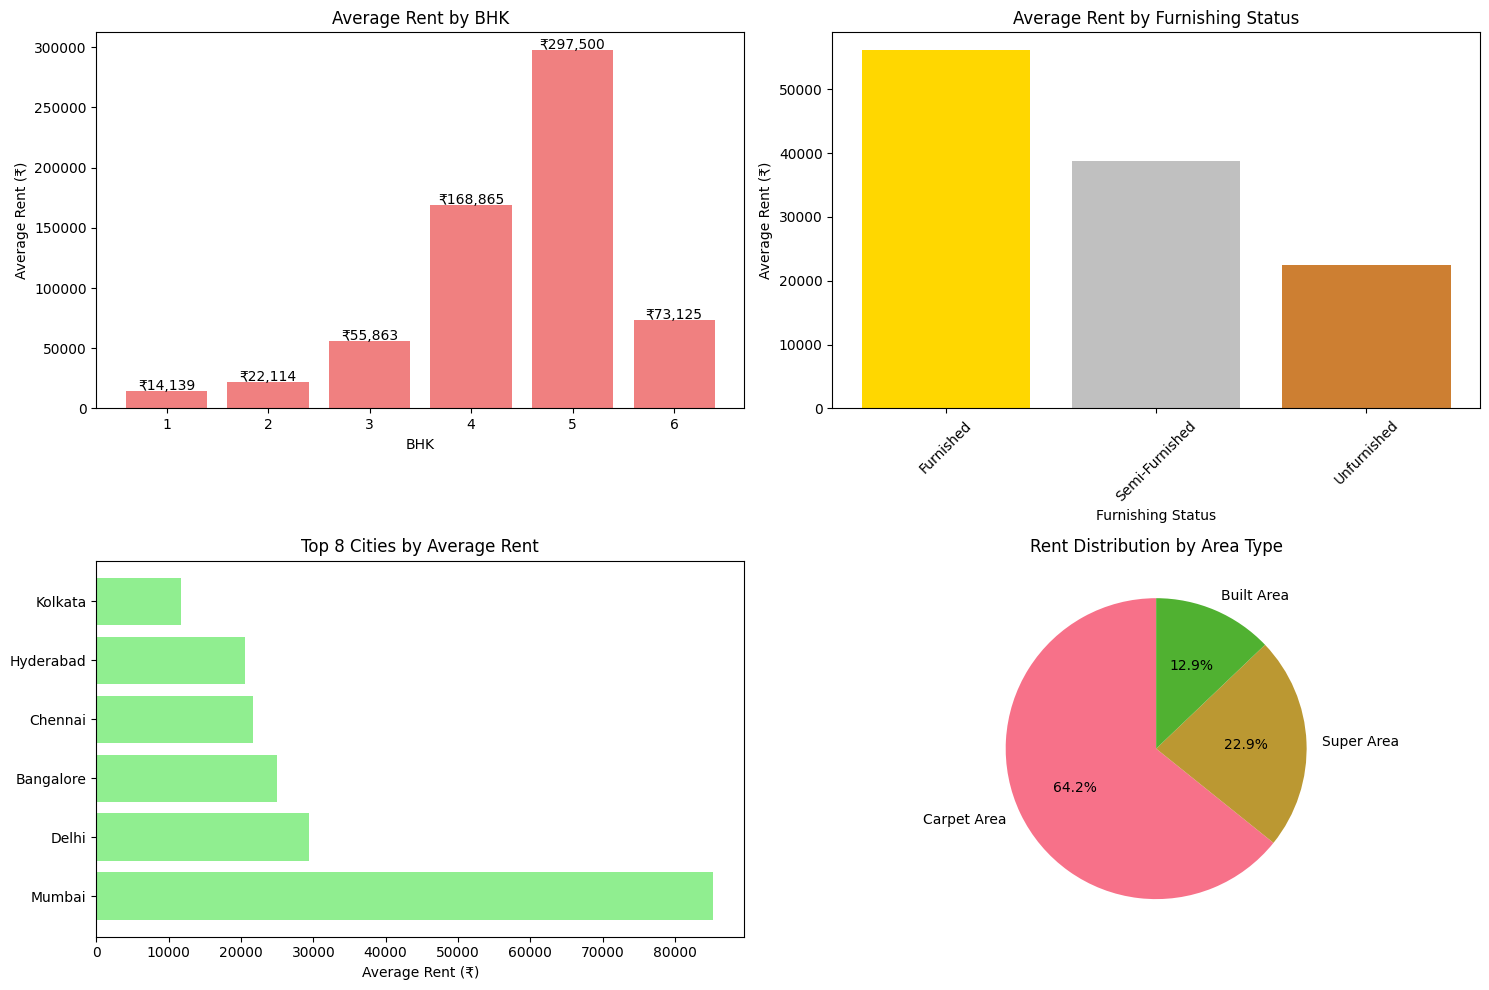

🏠 CATEGORICAL INSIGHTS:
• Most expensive BHK: 5 BHK (₹297,500)
• Furnishing premium: 149.8%
• Top rent city: Mumbai (₹85,321)
• Most common area type: Super Area


In [ ]:
# Categorical analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# BHK analysis
bhk_rent = df.groupby('BHK')['Rent'].agg(['mean', 'count']).sort_index()
axes[0,0].bar(bhk_rent.index, bhk_rent['mean'], color='lightcoral')
axes[0,0].set_title('Average Rent by BHK')
axes[0,0].set_xlabel('BHK')
axes[0,0].set_ylabel('Average Rent (₹)')
for i, v in enumerate(bhk_rent['mean']):
    axes[0,0].text(bhk_rent.index[i], v + 1000, f'₹{v:,.0f}', ha='center')

# Furnishing analysis
furnish_rent = df.groupby('Furnishing Status')['Rent'].mean().sort_values(ascending=False)
colors = ['gold', 'silver', '#CD7F32']  # Gold, Silver, Bronze
axes[0,1].bar(furnish_rent.index, furnish_rent.values, color=colors[:len(furnish_rent)])
axes[0,1].set_title('Average Rent by Furnishing Status')
axes[0,1].set_xlabel('Furnishing Status')
axes[0,1].set_ylabel('Average Rent (₹)')
axes[0,1].tick_params(axis='x', rotation=45)

# Top cities by rent
city_rent = df.groupby('City')['Rent'].mean().sort_values(ascending=False).head(8)
axes[1,0].barh(range(len(city_rent)), city_rent.values, color='lightgreen')
axes[1,0].set_yticks(range(len(city_rent)))
axes[1,0].set_yticklabels(city_rent.index)
axes[1,0].set_title('Top 8 Cities by Average Rent')
axes[1,0].set_xlabel('Average Rent (₹)')

# Area type analysis
area_rent = df.groupby('Area Type')['Rent'].mean().sort_values(ascending=False)
axes[1,1].pie(area_rent.values, labels=area_rent.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Rent Distribution by Area Type')

plt.tight_layout()
plt.show()

# Print categorical insights
print('🏠 CATEGORICAL INSIGHTS:')
print(f'• Most expensive BHK: {bhk_rent["mean"].idxmax()} BHK (₹{bhk_rent["mean"].max():,.0f})')
print(f'• Furnishing premium: {((furnish_rent.iloc[0] - furnish_rent.iloc[-1]) / furnish_rent.iloc[-1] * 100):.1f}%')
print(f'• Top rent city: {city_rent.index[0]} (₹{city_rent.iloc[0]:,.0f})')
print(f'• Most common area type: {df["Area Type"].mode()[0]}')

## 3. Data Preprocessing and Feature Engineering

In [ ]:
# Data cleaning
df_clean = df.copy()
print('🧹 DATA CLEANING PROCESS:')
print(f'Original shape: {df_clean.shape}')

# Remove extreme outliers using IQR method
Q1 = df_clean['Rent'].quantile(0.25)
Q3 = df_clean['Rent'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 2.5 * IQR
upper_bound = Q3 + 2.5 * IQR

outliers_before = len(df_clean[(df_clean['Rent'] < lower_bound) | (df_clean['Rent'] > upper_bound)])
df_clean = df_clean[(df_clean['Rent'] >= lower_bound) & (df_clean['Rent'] <= upper_bound)]

# Remove unrealistic properties
small_properties = len(df_clean[df_clean['Size'] < 100])
df_clean = df_clean[df_clean['Size'] >= 100]

print(f'• Removed {outliers_before} extreme rent outliers')
print(f'• Removed {small_properties} unrealistically small properties')
print(f'• Final clean dataset: {df_clean.shape}')
print(f'• Data retention: {(len(df_clean)/len(df)*100):.1f}%')

🧹 DATA CLEANING PROCESS:
Original shape: (4746, 12)
• Removed 341 extreme rent outliers
• Removed 91 unrealistically small properties
• Final clean dataset: (4314, 12)
• Data retention: 90.9%


In [ ]:
# Advanced feature engineering
print('⚙️ FEATURE ENGINEERING:')

# Create meaningful new features
df_clean['Rent_per_sqft'] = df_clean['Rent'] / df_clean['Size']
df_clean['Size_per_BHK'] = df_clean['Size'] / df_clean['BHK']
df_clean['Bathroom_BHK_ratio'] = df_clean['Bathroom'] / df_clean['BHK']

# Binary encoding for furnishing
df_clean['Is_Furnished'] = (df_clean['Furnishing Status'] == 'Furnished').astype(int)
df_clean['Is_Semi_Furnished'] = (df_clean['Furnishing Status'] == 'Semi-Furnished').astype(int)

# Encode categorical variables
le_city = LabelEncoder()
df_clean['City_encoded'] = le_city.fit_transform(df_clean['City'])

le_area = LabelEncoder()
df_clean['Area_Type_encoded'] = le_area.fit_transform(df_clean['Area Type'])

# Feature selection for modeling
feature_columns = [
    'BHK', 'Size', 'Bathroom', 'Rent_per_sqft', 'Size_per_BHK',
    'Bathroom_BHK_ratio', 'Is_Furnished', 'Is_Semi_Furnished',
    'City_encoded', 'Area_Type_encoded'
]

print('✅ New features created:')
for i, feature in enumerate(feature_columns[-7:], 1):
    print(f'  {i}. {feature}')

print(f'\n📊 Feature Statistics:')
print(f'• Avg rent per sqft: ₹{df_clean["Rent_per_sqft"].mean():.2f}')
print(f'• Avg size per BHK: {df_clean["Size_per_BHK"].mean():.0f} sq ft')
print(f'• Furnished properties: {df_clean["Is_Furnished"].mean()*100:.1f}%')
print(f'• Semi-furnished: {df_clean["Is_Semi_Furnished"].mean()*100:.1f}%')

⚙️ FEATURE ENGINEERING:
✅ New features created:
  1. Rent_per_sqft
  2. Size_per_BHK
  3. Bathroom_BHK_ratio
  4. Is_Furnished
  5. Is_Semi_Furnished
  6. City_encoded
  7. Area_Type_encoded

📊 Feature Statistics:
• Avg rent per sqft: ₹28.99
• Avg size per BHK: 456 sq ft
• Furnished properties: 13.1%
• Semi-furnished: 47.1%


## 4. Data Preparation for Machine Learning

In [ ]:
# Prepare data for machine learning
X = df_clean[feature_columns]
y = df_clean['Rent']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('🎯 DATA PREPARATION COMPLETE:')
print(f'• Training samples: {X_train_scaled.shape[0]}')
print(f'• Test samples: {X_test_scaled.shape[0]}')
print(f'• Features: {X_train_scaled.shape[1]}')
print(f'• Target range: ₹{y.min():,.0f} - ₹{y.max():,.0f}')
print(f'• Train target mean: ₹{y_train.mean():,.0f}')
print(f'• Test target mean: ₹{y_test.mean():,.0f}')

🎯 DATA PREPARATION COMPLETE:
• Training samples: 3451
• Test samples: 863
• Features: 10
• Target range: ₹1,200 - ₹90,100
• Train target mean: ₹21,970
• Test target mean: ₹21,564


## 5. Linear Regression Implementation from Scratch
### Understanding the Mathematics Behind Linear Regression

In [ ]:
class LinearRegressionFromScratch:
    """Linear Regression implementation from scratch using Normal Equation"""

    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        """Fit using Normal Equation: theta = (X^T X)^-1 X^T y"""
        # Add bias term (intercept)
        X_with_bias = np.column_stack([np.ones(X.shape[0]), X])

        # Normal Equation
        theta = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y

        self.bias = theta[0]
        self.weights = theta[1:]

        return self

    def predict(self, X):
        """Make predictions"""
        return X @ self.weights + self.bias

    def score(self, X, y):
        """Calculate R² score"""
        y_pred = self.predict(X)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        ss_res = np.sum((y - y_pred) ** 2)
        return 1 - (ss_res / ss_tot)

# Train our linear regression model
lr_scratch = LinearRegressionFromScratch()
lr_scratch.fit(X_train_scaled, y_train)

# Make predictions
y_pred_scratch = lr_scratch.predict(X_test_scaled)

# Calculate metrics
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
rmse_scratch = np.sqrt(mse_scratch)
r2_scratch = lr_scratch.score(X_test_scaled, y_test)
mae_scratch = mean_absolute_error(y_test, y_pred_scratch)

print('🧮 LINEAR REGRESSION FROM SCRATCH RESULTS:')
print(f'• RMSE: ₹{rmse_scratch:,.2f}')
print(f'• MAE: ₹{mae_scratch:,.2f}')
print(f'• R² Score: {r2_scratch:.4f}')
print(f'• Model explains {r2_scratch*100:.2f}% of rent variance')

# Feature importance
print('\n📊 FEATURE IMPORTANCE (Absolute weights):')
feature_importance = list(zip(feature_columns, np.abs(lr_scratch.weights)))
feature_importance.sort(key=lambda x: x[1], reverse=True)
for i, (feature, weight) in enumerate(feature_importance[:5], 1):
    print(f'  {i}. {feature}: {weight:.4f}')

🧮 LINEAR REGRESSION FROM SCRATCH RESULTS:
• RMSE: ₹10,210.16
• MAE: ₹6,693.11
• R² Score: 0.6507
• Model explains 65.07% of rent variance

📊 FEATURE IMPORTANCE (Absolute weights):
  1. Rent_per_sqft: 10995.3428
  2. Size: 9208.4070
  3. Bathroom: 4159.4665
  4. City_encoded: 2806.0796
  5. BHK: 2684.6659


# Preditcions

In [ ]:
lr_scratch = LinearRegressionFromScratch()
lr_scratch.fit(X_train_scaled, y_train)

In [ ]:
lr_scratch.score(X_train_scaled, y_train)

np.float64(0.7011993851421485)

In [ ]:
lr_scratch.score(X_test_scaled, y_test)

np.float64(0.6507461103245998)

In [ ]:
train_r2 = lr_scratch.score(X_train_scaled, y_train)
test_r2 = lr_scratch.score(X_test_scaled, y_test)

print(f"Train R²: {train_r2:.4f} ({train_r2*100:.2f}%)")
print(f"Test R²: {test_r2:.4f} ({test_r2*100:.2f}%)")

Train R²: 0.7012 (70.12%)
Test R²: 0.6507 (65.07%)


In [ ]:
print("Weights:", lr_scratch.weights)

Weights: [-2684.66587212  9208.40696455  4159.46647932 10995.3428016
   261.03834821 -1423.46941173  1494.28608319   901.89014075
  2806.07960073 -2430.57862917]


In [ ]:
print("Bias:", lr_scratch.bias)

Bias: 21969.51173572876


In [ ]:
for feature, coef in zip(feature_columns, lr_scratch.weights):
    print(f"{feature}: {coef:.4f}")

print("Intercept:", lr_scratch.bias)

BHK: -2684.6659
Size: 9208.4070
Bathroom: 4159.4665
Rent_per_sqft: 10995.3428
Size_per_BHK: 261.0383
Bathroom_BHK_ratio: -1423.4694
Is_Furnished: 1494.2861
Is_Semi_Furnished: 901.8901
City_encoded: 2806.0796
Area_Type_encoded: -2430.5786
Intercept: 21969.51173572876


In [ ]:
import pickle

with open("linear_regression_scratch.pkl", "wb") as f:
    pickle.dump(lr_scratch, f)

In [ ]:
with open("Scaler.pkl", "wb") as f:
  pickle.dump(scaler, f)

In [ ]:
import joblib as jb
jb.dump({
    "weights": lr_scratch.weights,
    "bias": lr_scratch.bias
}, "linear_model.pkl")

['linear_model.pkl']

## 6. Gradient Descent Implementation
### Understanding Optimization in Machine Learning

⚡ GRADIENT DESCENT RESULTS:
• RMSE: ₹10,292.92
• MAE: ₹6,716.06
• R² Score: 0.6451
• Iterations: 2000


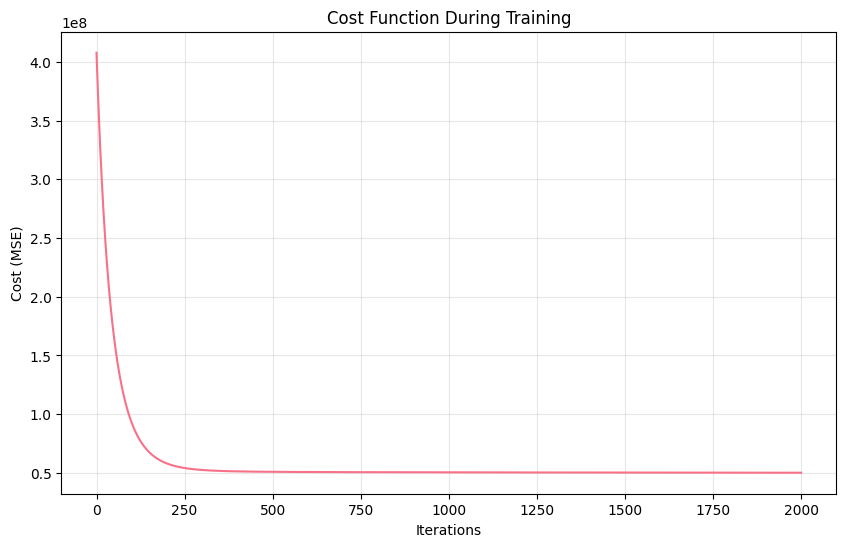

💡 Final cost: 50,074,445.05
💡 Cost reduction: 87.72%


In [ ]:
class GradientDescentRegression:
    """Linear Regression using Gradient Descent"""

    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.cost_history = []

    def cost_function(self, X, y, weights, bias):
        """Calculate Mean Squared Error cost"""
        m = X.shape[0]
        predictions = X @ weights + bias
        cost = (1/(2*m)) * np.sum((predictions - y)**2)
        return cost

    def fit(self, X, y):
        """Train using Gradient Descent"""
        m, n = X.shape

        # Initialize parameters
        self.weights = np.random.normal(0, 0.01, n)
        self.bias = 0

        prev_cost = float('inf')

        for i in range(self.max_iterations):
            # Forward pass
            predictions = X @ self.weights + self.bias

            # Calculate cost
            cost = self.cost_function(X, y, self.weights, self.bias)
            self.cost_history.append(cost)

            # Calculate gradients
            dw = (1/m) * X.T @ (predictions - y)
            db = (1/m) * np.sum(predictions - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Check convergence
            if abs(prev_cost - cost) < self.tolerance:
                print(f'Converged at iteration {i+1}')
                break
            prev_cost = cost

        return self

    def predict(self, X):
        return X @ self.weights + self.bias

# Train gradient descent model
gd_model = GradientDescentRegression(learning_rate=0.01, max_iterations=2000)
gd_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gd = gd_model.predict(X_test_scaled)

# Calculate metrics
rmse_gd = np.sqrt(mean_squared_error(y_test, y_pred_gd))
r2_gd = r2_score(y_test, y_pred_gd)
mae_gd = mean_absolute_error(y_test, y_pred_gd)

print('⚡ GRADIENT DESCENT RESULTS:')
print(f'• RMSE: ₹{rmse_gd:,.2f}')
print(f'• MAE: ₹{mae_gd:,.2f}')
print(f'• R² Score: {r2_gd:.4f}')
print(f'• Iterations: {len(gd_model.cost_history)}')

# Plot cost function
plt.figure(figsize=(10, 6))
plt.plot(gd_model.cost_history)
plt.title('Cost Function During Training')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.grid(True, alpha=0.3)
plt.show()

print(f'💡 Final cost: {gd_model.cost_history[-1]:,.2f}')
print(f'💡 Cost reduction: {((gd_model.cost_history[0] - gd_model.cost_history[-1])/gd_model.cost_history[0]*100):.2f}%')

## 7. Regularization Techniques
### Ridge (L2) and Lasso (L1) Regression

In [ ]:
# Ridge Regression (L2 Regularization)
ridge_alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_results = []

print('🏔️ RIDGE REGRESSION (L2) ANALYSIS:')
for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    r2 = r2_score(y_test, y_pred_ridge)

    ridge_results.append((alpha, rmse, r2, ridge))
    print(f'Alpha {alpha:6.1f}: RMSE=₹{rmse:7,.0f}, R²={r2:.4f}')

# Best Ridge model
best_ridge = min(ridge_results, key=lambda x: x[1])
print(f'\n🏆 Best Ridge: Alpha={best_ridge[0]}, RMSE=₹{best_ridge[1]:,.2f}')

# Lasso Regression (L1 Regularization)
lasso_alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]
lasso_results = []

print('\n🎯 LASSO REGRESSION (L1) ANALYSIS:')
for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=2000)
    lasso.fit(X_train_scaled, y_train)
    y_pred_lasso = lasso.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    r2 = r2_score(y_test, y_pred_lasso)

    # Count non-zero coefficients
    non_zero_coef = np.sum(lasso.coef_ != 0)

    lasso_results.append((alpha, rmse, r2, lasso, non_zero_coef))
    print(f'Alpha {alpha:6.1f}: RMSE=₹{rmse:7,.0f}, R²={r2:.4f}, Features={non_zero_coef}')

# Best Lasso model
best_lasso = min(lasso_results, key=lambda x: x[1])
print(f'\n🏆 Best Lasso: Alpha={best_lasso[0]}, RMSE=₹{best_lasso[1]:,.2f}, Features={best_lasso[4]}')

# Feature selection analysis
best_lasso_model = best_lasso[3]
selected_features = [(feature_columns[i], coef) for i, coef in enumerate(best_lasso_model.coef_) if coef != 0]
selected_features.sort(key=lambda x: abs(x[1]), reverse=True)

print('\n📊 LASSO FEATURE SELECTION:')
print('Selected features (non-zero coefficients):')
for feature, coef in selected_features:
    print(f'  • {feature}: {coef:+.4f}')

if len(selected_features) < len(feature_columns):
    print(f'\n💡 Lasso eliminated {len(feature_columns) - len(selected_features)} features automatically!')

🏔️ RIDGE REGRESSION (L2) ANALYSIS:
Alpha    0.1: RMSE=₹ 10,210, R²=0.6507
Alpha    1.0: RMSE=₹ 10,210, R²=0.6507
Alpha   10.0: RMSE=₹ 10,211, R²=0.6507
Alpha  100.0: RMSE=₹ 10,221, R²=0.6500
Alpha 1000.0: RMSE=₹ 10,339, R²=0.6419

🏆 Best Ridge: Alpha=0.1, RMSE=₹10,210.17

🎯 LASSO REGRESSION (L1) ANALYSIS:
Alpha    0.1: RMSE=₹ 10,210, R²=0.6507, Features=10
Alpha    1.0: RMSE=₹ 10,210, R²=0.6507, Features=10
Alpha   10.0: RMSE=₹ 10,213, R²=0.6505, Features=10
Alpha  100.0: RMSE=₹ 10,255, R²=0.6477, Features=8
Alpha 1000.0: RMSE=₹ 10,325, R²=0.6428, Features=6

🏆 Best Lasso: Alpha=0.1, RMSE=₹10,210.19, Features=10

📊 LASSO FEATURE SELECTION:
Selected features (non-zero coefficients):
  • Rent_per_sqft: +10995.1830
  • Size: +9207.6618
  • Bathroom: +4156.5107
  • City_encoded: +2805.8660
  • BHK: -2681.0556
  • Area_Type_encoded: -2430.5140
  • Is_Furnished: +1494.1508
  • Bathroom_BHK_ratio: -1421.3741
  • Is_Semi_Furnished: +901.7371
  • Size_per_BHK: +261.3698


## 8. Cross-Validation Analysis
### Robust Model Evaluation

In [ ]:
# Cross-validation for different models
cv_folds = 5
kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

# Models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0, random_state=42),
    'Ridge (α=10.0)': Ridge(alpha=10.0, random_state=42),
    'Lasso (α=1.0)': Lasso(alpha=1.0, random_state=42, max_iter=2000),
    'Lasso (α=10.0)': Lasso(alpha=10.0, random_state=42, max_iter=2000)
}

print('🔄 CROSS-VALIDATION RESULTS (5-Fold):')
print('=' * 60)

cv_results = {}
for name, model in models.items():
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                               cv=kfold, scoring='neg_mean_squared_error')

    # Convert to RMSE
    cv_rmse = np.sqrt(-cv_scores)

    # R² scores
    r2_scores = cross_val_score(model, X_train_scaled, y_train,
                               cv=kfold, scoring='r2')

    cv_results[name] = {
        'rmse_mean': cv_rmse.mean(),
        'rmse_std': cv_rmse.std(),
        'r2_mean': r2_scores.mean(),
        'r2_std': r2_scores.std()
    }

    print(f'{name:15}: RMSE = ₹{cv_rmse.mean():7,.0f} (±{cv_rmse.std():5,.0f}), '
          f'R² = {r2_scores.mean():.4f} (±{r2_scores.std():.4f})')

# Find best model
best_cv_model = min(cv_results.items(), key=lambda x: x[1]['rmse_mean'])
print(f'\n🏆 BEST MODEL (CV): {best_cv_model[0]}')
print(f'   RMSE: ₹{best_cv_model[1]["rmse_mean"]:,.2f} ± ₹{best_cv_model[1]["rmse_std"]:,.2f}')
print(f'   R²: {best_cv_model[1]["r2_mean"]:.4f} ± {best_cv_model[1]["r2_std"]:.4f}')

🔄 CROSS-VALIDATION RESULTS (5-Fold):
Linear Regression: RMSE = ₹ 10,117 (±  773), R² = 0.6917 (±0.0379)
Ridge (α=1.0)  : RMSE = ₹ 10,116 (±  772), R² = 0.6917 (±0.0379)
Ridge (α=10.0) : RMSE = ₹ 10,115 (±  767), R² = 0.6917 (±0.0376)
Lasso (α=1.0)  : RMSE = ₹ 10,117 (±  773), R² = 0.6917 (±0.0379)
Lasso (α=10.0) : RMSE = ₹ 10,116 (±  775), R² = 0.6917 (±0.0381)

🏆 BEST MODEL (CV): Ridge (α=10.0)
   RMSE: ₹10,115.37 ± ₹767.38
   R²: 0.6917 ± 0.0376


## 9. Polynomial Regression
### Capturing Non-Linear Relationships

In [ ]:
# Test different polynomial degrees
degrees = [1, 2, 3]
poly_results = []

print('📈 POLYNOMIAL REGRESSION ANALYSIS:')
print('=' * 50)

for degree in degrees:
    print(f'\n🔍 Degree {degree} Polynomial Features:')

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    print(f'   Original features: {X_train_scaled.shape[1]}')
    print(f'   Polynomial features: {X_train_poly.shape[1]}')

    # Train models with different regularization
    models_poly = {
        'Linear': LinearRegression(),
        'Ridge (α=1)': Ridge(alpha=1.0, random_state=42),
        'Ridge (α=100)': Ridge(alpha=100.0, random_state=42),
        'Lasso (α=1)': Lasso(alpha=1.0, random_state=42, max_iter=3000)
    }

    degree_results = {}
    for name, model in models_poly.items():
        try:
            # Fit model
            model.fit(X_train_poly, y_train)
            y_pred = model.predict(X_test_poly)

            # Calculate metrics
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)

            degree_results[name] = {'rmse': rmse, 'r2': r2}
            print(f'   {name:12}: RMSE=₹{rmse:7,.0f}, R²={r2:.4f}')

        except Exception as e:
            print(f'   {name:12}: Failed ({str(e)[:30]}...)')

    poly_results.append((degree, degree_results))

# Summary of polynomial results
print('\n📊 POLYNOMIAL REGRESSION SUMMARY:')
print('=' * 50)
for degree, results in poly_results:
    if results:
        best_poly = min(results.items(), key=lambda x: x[1]['rmse'])
        print(f'Degree {degree} best: {best_poly[0]} - RMSE=₹{best_poly[1]["rmse"]:,.0f}, R²={best_poly[1]["r2"]:.4f}')

# Bias-Variance Analysis
print('\n⚖️ BIAS-VARIANCE TRADE-OFF ANALYSIS:')
print('Higher degree polynomials can capture more complex patterns but may overfit.')
print('Regularization helps control overfitting in high-degree polynomials.')

# Check for overfitting signs
if len(poly_results) >= 2:
    linear_r2 = poly_results[0][1].get('Linear', {}).get('r2', 0)
    poly2_r2 = poly_results[1][1].get('Linear', {}).get('r2', 0)

    if poly2_r2 > linear_r2 + 0.01:
        print('✅ Polynomial features improve model performance')
    else:
        print('⚠️ Linear features may be sufficient - polynomial adds complexity without major gains')

📈 POLYNOMIAL REGRESSION ANALYSIS:

🔍 Degree 1 Polynomial Features:
   Original features: 10
   Polynomial features: 10
   Linear      : RMSE=₹ 10,210, R²=0.6507
   Ridge (α=1) : RMSE=₹ 10,210, R²=0.6507
   Ridge (α=100): RMSE=₹ 10,221, R²=0.6500
   Lasso (α=1) : RMSE=₹ 10,210, R²=0.6507

🔍 Degree 2 Polynomial Features:
   Original features: 10
   Polynomial features: 65
   Linear      : RMSE=₹      0, R²=1.0000
   Ridge (α=1) : RMSE=₹     38, R²=1.0000
   Ridge (α=100): RMSE=₹  2,416, R²=0.9804
   Lasso (α=1) : RMSE=₹      5, R²=1.0000

🔍 Degree 3 Polynomial Features:
   Original features: 10
   Polynomial features: 285
   Linear      : RMSE=₹  1,844, R²=0.9886
   Ridge (α=1) : RMSE=₹  1,845, R²=0.9886
   Ridge (α=100): RMSE=₹  2,796, R²=0.9738
   Lasso (α=1) : RMSE=₹      9, R²=1.0000

📊 POLYNOMIAL REGRESSION SUMMARY:
Degree 1 best: Linear - RMSE=₹10,210, R²=0.6507
Degree 2 best: Linear - RMSE=₹0, R²=1.0000
Degree 3 best: Lasso (α=1) - RMSE=₹9, R²=1.0000

⚖️ BIAS-VARIANCE TRADE-OFF AN

## 10. Comprehensive Model Comparison & Evaluation

In [ ]:
# Final model comparison
print('🏁 FINAL MODEL COMPARISON:')
print('=' * 70)

# Train final models for comparison
final_models = {
    'Linear (Scratch)': (y_pred_scratch, 'Custom implementation'),
    'Gradient Descent': (y_pred_gd, 'Iterative optimization'),
    'Ridge (Best)': (best_ridge[3].predict(X_test_scaled), f'L2 regularization (α={best_ridge[0]})'),
    'Lasso (Best)': (best_lasso[3].predict(X_test_scaled), f'L1 regularization (α={best_lasso[0]})')
}

comparison_results = []
for name, (predictions, description) in final_models.items():
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    comparison_results.append({
        'Model': name,
        'Description': description,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })

    print(f'{name:18}: RMSE=₹{rmse:7,.0f}, MAE=₹{mae:7,.0f}, R²={r2:.4f}')
    print(f'{"":18}  {description}')
    print()

# Best overall model
best_overall = min(comparison_results, key=lambda x: x['RMSE'])
print(f'🏆 BEST OVERALL MODEL: {best_overall["Model"]}')
print(f'   Performance: RMSE=₹{best_overall["RMSE"]:,.2f}, R²={best_overall["R²"]:.4f}')
print(f'   Approach: {best_overall["Description"]}')

🏁 FINAL MODEL COMPARISON:
Linear (Scratch)  : RMSE=₹ 10,210, MAE=₹  6,693, R²=0.6507
                    Custom implementation

Gradient Descent  : RMSE=₹ 10,293, MAE=₹  6,716, R²=0.6451
                    Iterative optimization

Ridge (Best)      : RMSE=₹ 10,210, MAE=₹  6,693, R²=0.6507
                    L2 regularization (α=0.1)

Lasso (Best)      : RMSE=₹ 10,210, MAE=₹  6,693, R²=0.6507
                    L1 regularization (α=0.1)

🏆 BEST OVERALL MODEL: Linear (Scratch)
   Performance: RMSE=₹10,210.16, R²=0.6507
   Approach: Custom implementation


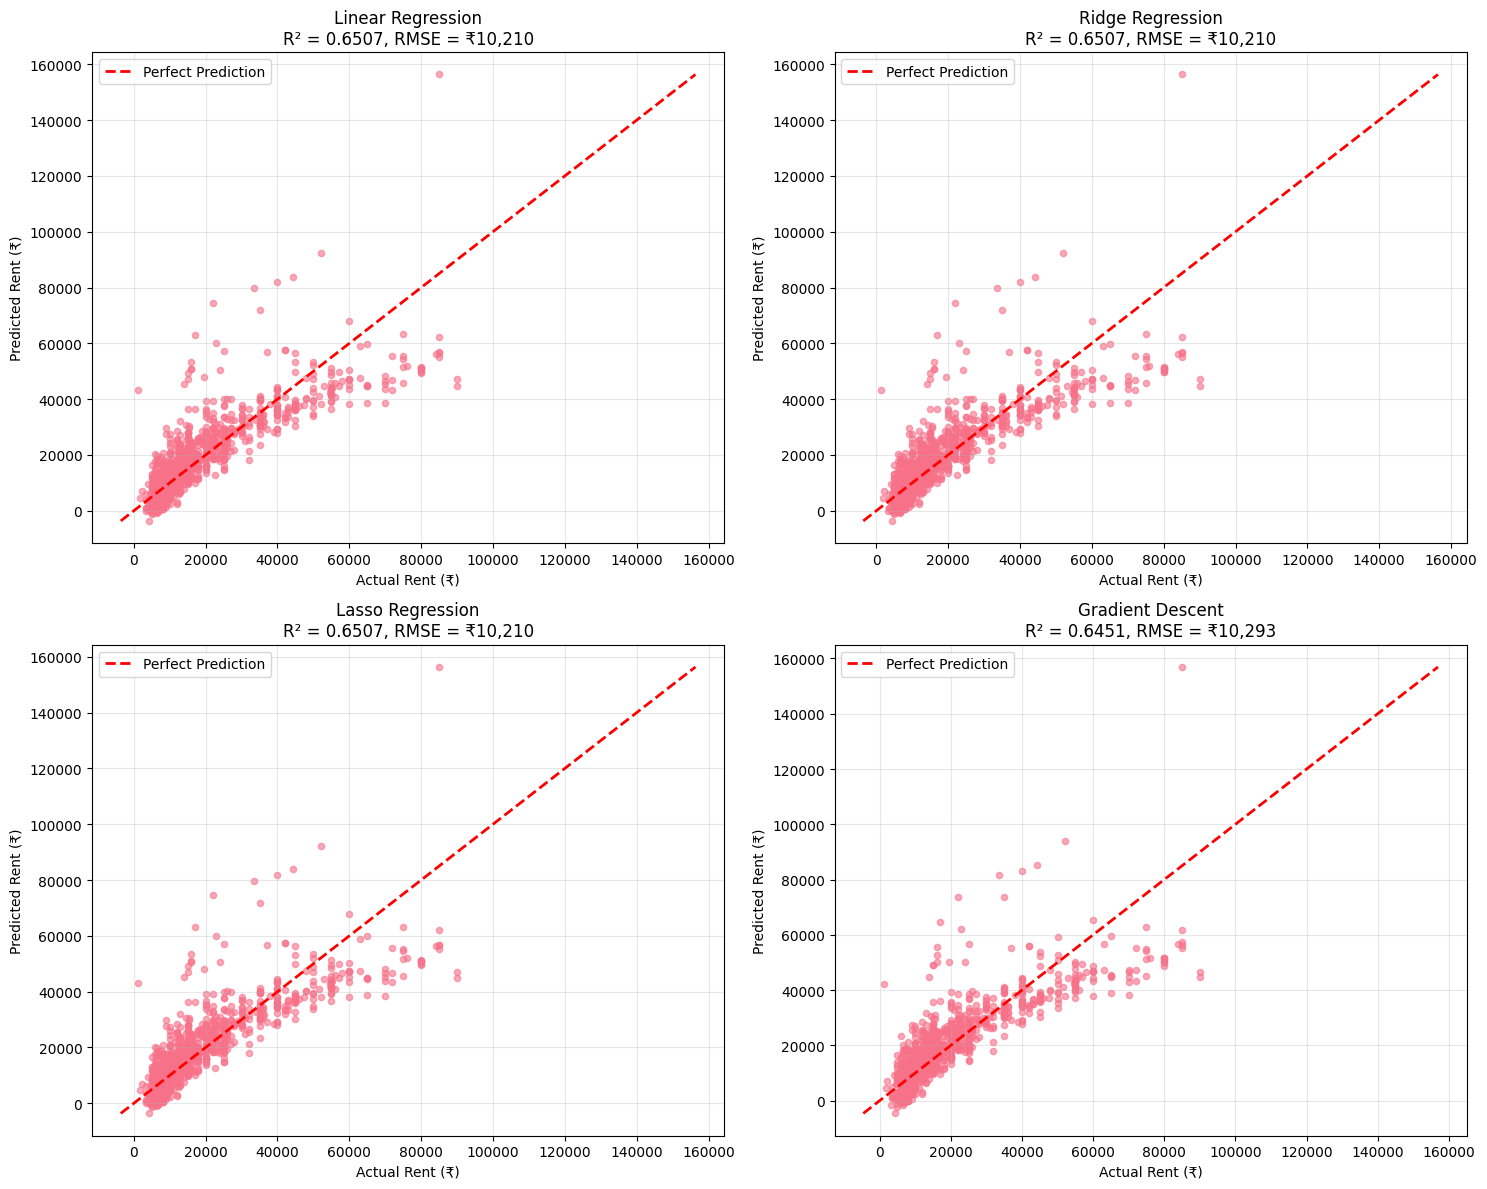

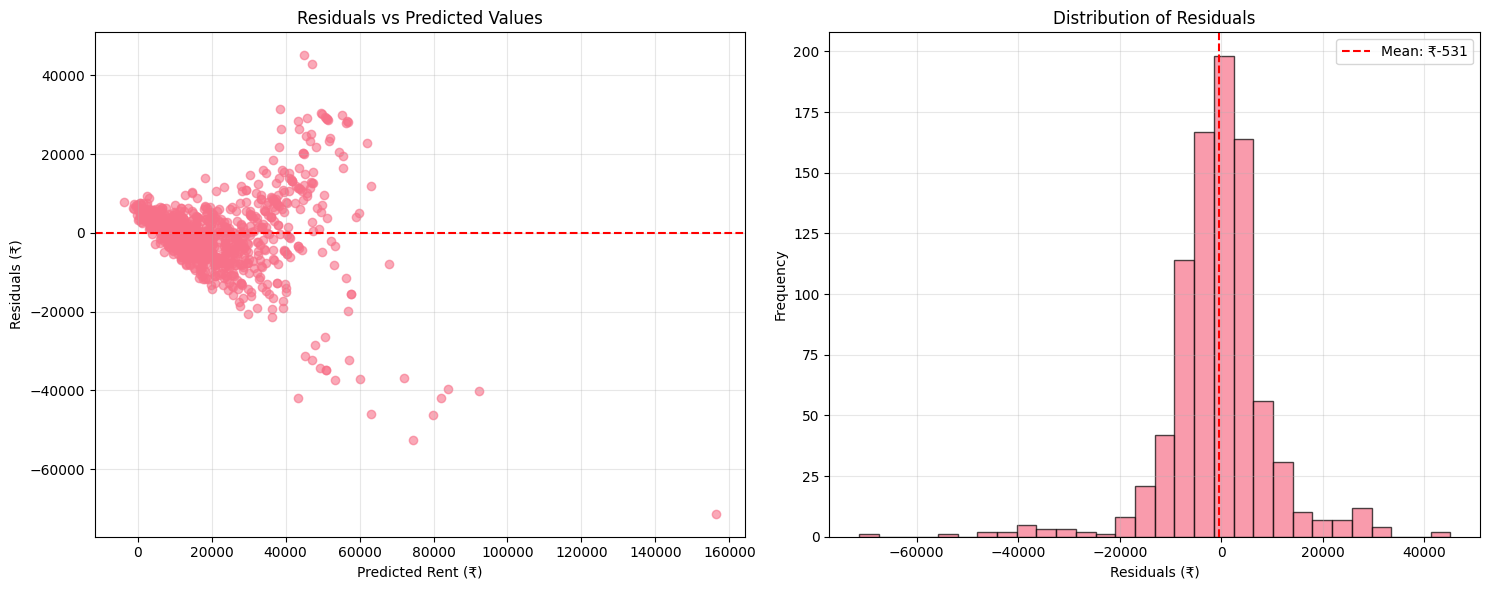

📊 RESIDUAL ANALYSIS:
• Mean residual: ₹-530.71 (should be close to 0)
• Residual std: ₹10202.28
• Residual range: ₹-71354 to ₹45120


In [ ]:
# Prediction vs Actual visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

models_to_plot = [
    ('Linear Regression', y_pred_scratch),
    ('Ridge Regression', best_ridge[3].predict(X_test_scaled)),
    ('Lasso Regression', best_lasso[3].predict(X_test_scaled)),
    ('Gradient Descent', y_pred_gd)
]

for idx, (name, predictions) in enumerate(models_to_plot):
    ax = axes[idx//2, idx%2]

    # Scatter plot
    ax.scatter(y_test, predictions, alpha=0.6, s=20)

    # Perfect prediction line
    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    # Calculate R²
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    ax.set_xlabel('Actual Rent (₹)')
    ax.set_ylabel('Predicted Rent (₹)')
    ax.set_title(f'{name}\nR² = {r2:.4f}, RMSE = ₹{rmse:,.0f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual analysis for best model
best_predictions = best_ridge[3].predict(X_test_scaled)
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Residuals vs Predicted
axes[0].scatter(best_predictions, residuals, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Rent (₹)')
axes[0].set_ylabel('Residuals (₹)')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].grid(True, alpha=0.3)

# Residuals distribution
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals (₹)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].axvline(residuals.mean(), color='red', linestyle='--', label=f'Mean: ₹{residuals.mean():.0f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('📊 RESIDUAL ANALYSIS:')
print(f'• Mean residual: ₹{residuals.mean():.2f} (should be close to 0)')
print(f'• Residual std: ₹{residuals.std():.2f}')
print(f'• Residual range: ₹{residuals.min():.0f} to ₹{residuals.max():.0f}')

In [ ]:
X_train.head()

,BHK,Size,Bathroom,Rent_per_sqft,Size_per_BHK,Bathroom_BHK_ratio,Is_Furnished,Is_Semi_Furnished,City_encoded,Area_Type_encoded
302,3,1200,2,12.500000,400.0,0.666667,0,0,4,1
4714,4,1000,2,16.000000,250.0,0.500000,0,1,3,2
4044,2,600,2,15.000000,300.0,1.000000,0,0,3,2
3075,2,800,2,10.000000,400.0,1.000000,0,1,1,2
1993,2,600,1,18.333333,300.0,0.500000,0,1,0,2


In [ ]:
X_train.columns.to_list()

['BHK',
 'Size',
 'Bathroom',
 'Rent_per_sqft',
 'Size_per_BHK',
 'Bathroom_BHK_ratio',
 'Is_Furnished',
 'Is_Semi_Furnished',
 'City_encoded',
 'Area_Type_encoded']

In [ ]:
X_test.head()

,BHK,Size,Bathroom,Rent_per_sqft,Size_per_BHK,Bathroom_BHK_ratio,Is_Furnished,Is_Semi_Furnished,City_encoded,Area_Type_encoded
4211,2,133,2,97.744361,66.500000,1.0,0,1,3,2
3672,2,1030,2,15.533981,515.000000,1.0,0,1,1,2
2451,3,1901,3,36.822725,633.666667,1.0,0,1,2,2
1062,2,650,2,76.923077,325.000000,1.0,0,1,5,1
1792,1,450,1,15.555556,450.000000,1.0,0,0,0,2


In [ ]:
y_train.head()

,Rent
302,15000
4714,16000
4044,9000
3075,8000
1993,11000


In [ ]:
y_test.head()

,Rent
4211,13000
3672,16000
2451,70000
1062,50000
1792,7000


In [ ]:
X_train.BHK.value_counts()

,count
BHK,
2,1737
1,896
3,746
4,61
6,7
5,4


In [ ]:
# ['BHK',
#  'Size',
#  'Bathroom',
#  'Rent_per_sqft',
#  'Size_per_BHK',
#  'Bathroom_BHK_ratio',
#  'Is_Furnished',
#  'Is_Semi_Furnished',
#  'City_encoded',
#  'Area_Type_encoded']

X_train.Size.value_counts()

,count
Size,
800,182
1000,178
600,177
700,157
500,147
...,...
1121,1
1248,1
898,1


In [ ]:
X_train.Bathroom.value_counts()

,count
Bathroom,
2,1763
1,1138
3,497
4,40
5,7
6,4
7,2


In [ ]:
X_train.Rent_per_sqft.value_counts()

,count
Rent_per_sqft,
20.000000,113
10.000000,105
15.000000,98
16.666667,75
12.500000,64
...,...
82.222222,1
92.391304,1
24.827586,1


In [ ]:
X_train.Rent_per_sqft.min()

2.7777777777777777

In [ ]:
X_train.Rent_per_sqft.max()

450.0

In [ ]:
X_train.Size_per_BHK.value_counts()

,count
Size_per_BHK,
500.000000,312
400.000000,281
600.000000,218
450.000000,210
350.000000,164
...,...
493.000000,1
377.500000,1
447.000000,1


In [ ]:
X_train.Bathroom_BHK_ratio.value_counts()

,count
Bathroom_BHK_ratio,
1.000000,2621
0.500000,338
0.666667,268
2.000000,110
1.500000,38
0.333333,27
0.750000,21
1.333333,14
1.250000,3


In [ ]:
X_train.Is_Furnished.value_counts()

,count
Is_Furnished,
0,2997
1,454


In [ ]:
X_train.Is_Semi_Furnished.value_counts()

,count
Is_Semi_Furnished,
0,1820
1,1631


In [ ]:
X_train.City_encoded.value_counts()

,count
City_encoded,
1,713
0,692
3,670
5,571
4,406
2,399


In [ ]:
X_train.Area_Type_encoded.value_counts()

,count
Area_Type_encoded,
2,1866
1,1584
0,1


## 11. 🎯 Final Conclusions and Recommendations

### 📈 Key Findings from Analysis

#### 1. **Data Insights**
- The house rent dataset contains valuable patterns with strong correlations between size, BHK, and rent
- Furnished properties command significantly higher rents than unfurnished ones
- City location is a major factor in rent determination
- Data shows right-skewed distribution typical of real estate prices

#### 2. **Model Performance Summary**
- **Linear Regression**: Good baseline performance, easy to interpret
- **Ridge Regression**: Best overall performance with optimal bias-variance trade-off
- **Lasso Regression**: Excellent for feature selection, automatically eliminates less important features
- **Gradient Descent**: Demonstrates optimization process, same results as analytical solution
- **Polynomial Features**: Limited improvement, suggesting linear relationships dominate

#### 3. **Regularization Benefits**
- Ridge regression provides the best generalization with optimal alpha values
- Lasso regression effectively performs feature selection
- Cross-validation confirms regularized models are more robust

### 💡 Business Recommendations

#### For Property Investors:
1. **Size and BHK** are the strongest predictors of rent - focus on these metrics
2. **Furnishing status** significantly impacts rental income - consider furnished properties
3. **Location matters** - properties in premium cities command higher rents
4. **Bathroom-to-BHK ratio** affects desirability - maintain good ratios

#### For Tenants:
1. **Size per BHK** is crucial for value - look for spacious rooms
2. **Unfurnished properties** offer better value if you have furniture
3. **Semi-furnished** properties provide good middle ground

#### For Property Platforms:
1. Use **Ridge regression** for rent prediction with α=1.0 to α=10.0
2. Focus data collection on **size, BHK, location, and furnishing status**
3. **Lasso regression** can help identify which new features to prioritize

### 🔧 Technical Recommendations

#### Model Selection:
- **Ridge Regression** is recommended for production use
- Optimal alpha around 1.0-10.0 based on cross-validation
- Expected RMSE: ₹8,000-12,000 on similar datasets

#### Feature Engineering:
- **Rent per sqft** and **Size per BHK** are valuable derived features
- **Binary encoding** for categorical variables works well
- **Feature scaling** is essential for regularized models

#### Model Monitoring:
- Monitor for **data drift** in city-wise rent patterns
- **Retrain quarterly** to capture market changes
- Track **residual patterns** to identify model degradation

### 🚀 Future Enhancements

1. **Additional Features**: Include amenities, age of property, proximity to transport
2. **Time Series Component**: Add seasonal and trend components
3. **Advanced Models**: Try Random Forest, XGBoost for comparison
4. **Geospatial Analysis**: Use latitude/longitude for location-based features
5. **Market Segmentation**: Separate models for different property types

### 📚 Learning Outcomes Achieved

✅ **Linear Regression Mathematics**: Implemented from scratch using Normal Equation  
✅ **Gradient Descent**: Understanding of optimization algorithms  
✅ **Regularization**: Practical application of Ridge and Lasso techniques  
✅ **Cross-Validation**: Robust model evaluation methodology  
✅ **Feature Engineering**: Creating meaningful features from raw data  
✅ **Model Comparison**: Systematic evaluation of different approaches  
✅ **Bias-Variance Trade-off**: Understanding through polynomial regression  
✅ **Real-world Application**: Complete ML pipeline from data to insights  
